# 05. Model Comparison
**Goal:** Bring everything together and evaluate all models systematically to declare a winner.

### 1. Load & Display Metrics Table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Load metrics
ml_metrics = pd.read_csv('../data/classical_metrics.csv')
lstm_metrics = pd.read_csv('../data/lstm_metrics.csv')

# Combine all metrics
all_metrics = pd.concat([ml_metrics, lstm_metrics], ignore_index=True)

# Function to highlight best (min) and worst (max) values column-wise
def highlight_min_max(s):
    # Only color numeric columns
    if s.dtype == 'object':
        return ['' for _ in s]
    
    is_min = s == s.min()
    is_max = s == s.max()
    
    styles = []
    # Since all current metrics (RMSE, MAE, NASA_Score) are "lower is better"
    for min_val, max_val in zip(is_min, is_max):
        if min_val:
            styles.append('background-color: lightgreen; color: black; font-weight: bold')
        elif max_val:
            styles.append('background-color: lightcoral; color: black; font-weight: bold')
        else:
            styles.append('')
    return styles

# Apply style and render in notebook
styled_table = all_metrics.style.apply(highlight_min_max)
display(styled_table)

,Model,RMSE,MAE,NASA_Score
0,Random Forest,18.302650,13.703500,734.518896
1,XGBoost,17.113900,12.844292,586.420883
2,LSTM,80.271719,68.677628,330225.325565


### 2. Bar Chart Comparison

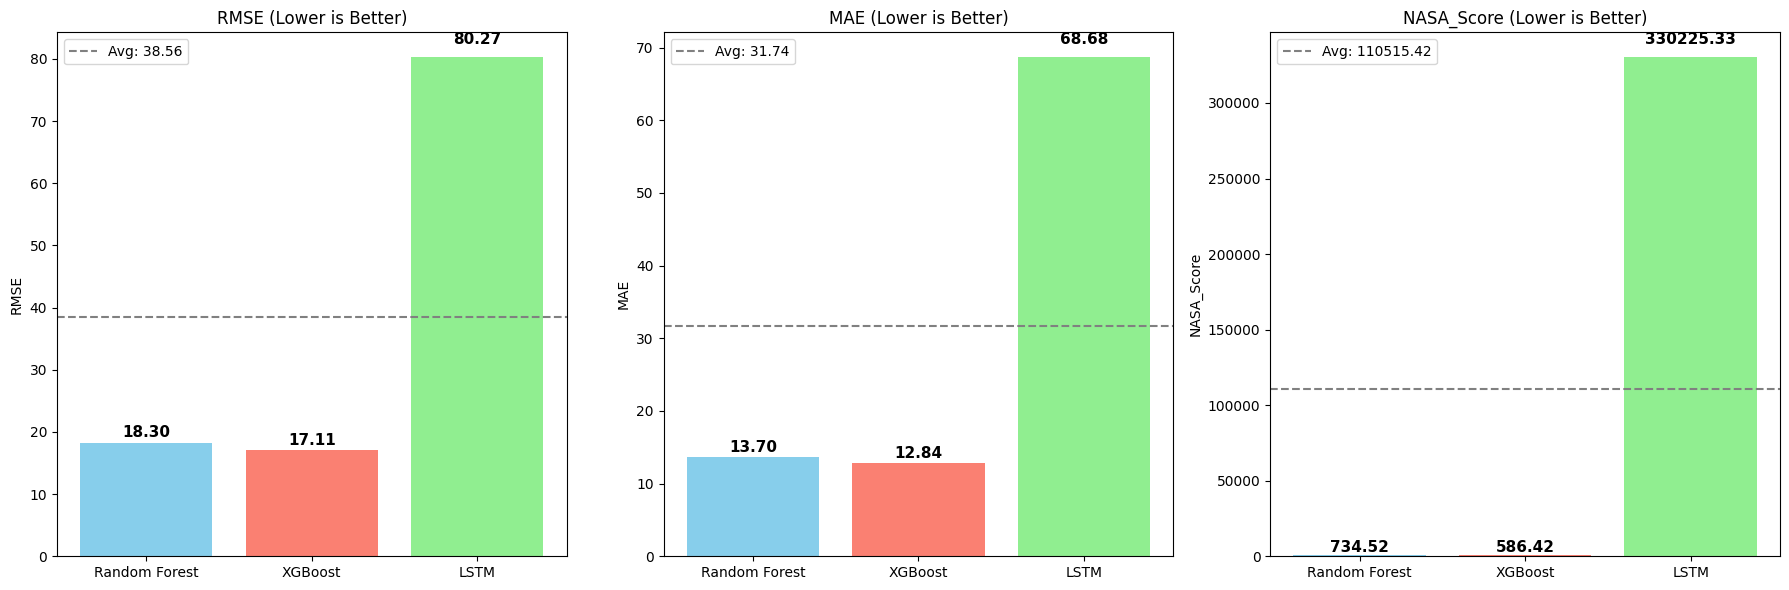

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = ['RMSE', 'MAE', 'NASA_Score']
colors = ['skyblue', 'salmon', 'lightgreen', 'plum'] 

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    bars = ax.bar(all_metrics['Model'], all_metrics[metric], color=colors[:len(all_metrics)])
    
    # Horizontal dash line for average
    avg_val = all_metrics[metric].mean()
    ax.axhline(avg_val, color='gray', linestyle='--', label=f'Avg: {avg_val:.2f}')
    
    # Value labels on top of bars
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 * bar.get_height(), 
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
                
    ax.set_title(f'{metric} (Lower is Better)')
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

### 3. Predicted vs Actual Overlay

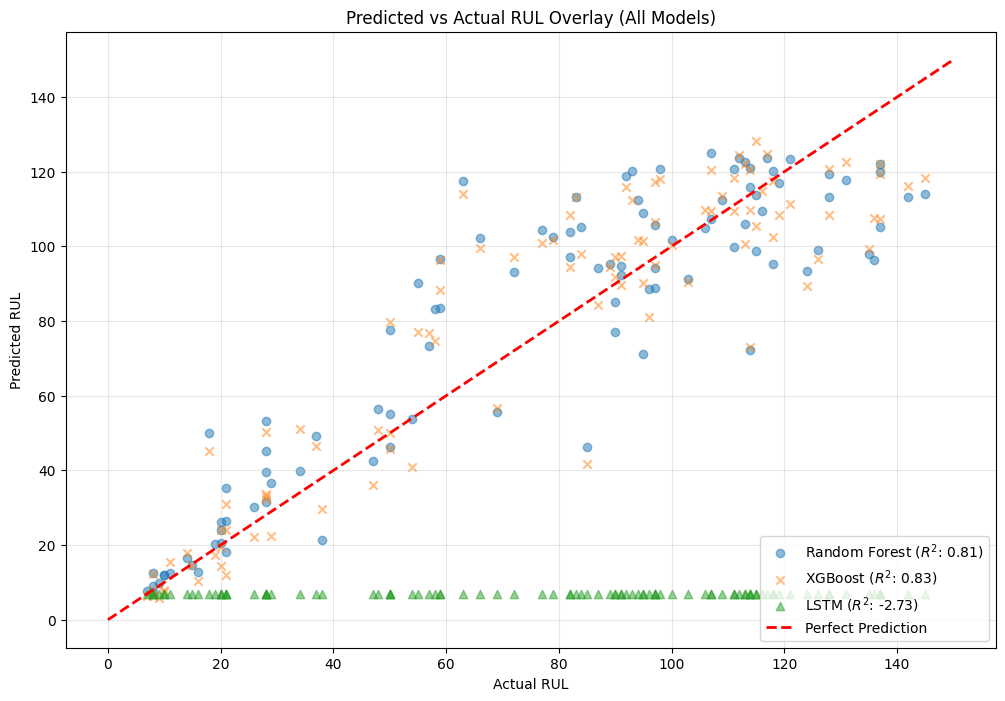

In [3]:
# Load numerical predictions from tests
ml_preds = pd.read_csv('../data/ml_preds.csv')
lstm_preds = pd.read_csv('../data/lstm_preds.csv')

actual_rul = ml_preds['Actual']
models_dict = {}

# Reconstruct predictions dict
if 'RF' in ml_preds.columns:
    models_dict['Random Forest'] = ml_preds['RF']
if 'XGB' in ml_preds.columns:
    models_dict['XGBoost'] = ml_preds['XGB']

dl_col = lstm_preds.columns[0]
models_dict[dl_col] = lstm_preds[dl_col]

plt.figure(figsize=(12, 8))
markers = ['o', 'x', '^', 's']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (name, preds) in enumerate(models_dict.items()):
    r2 = r2_score(actual_rul, preds)
    plt.scatter(actual_rul, preds, alpha=0.5, 
                label=f'{name} ($R^2$: {r2:.2f})', 
                marker=markers[i % len(markers)], color=colors[i % len(colors)])

# Perfect prediction line
plt.plot([0, 150], [0, 150], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL Overlay (All Models)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### 4. Error Distribution Comparison

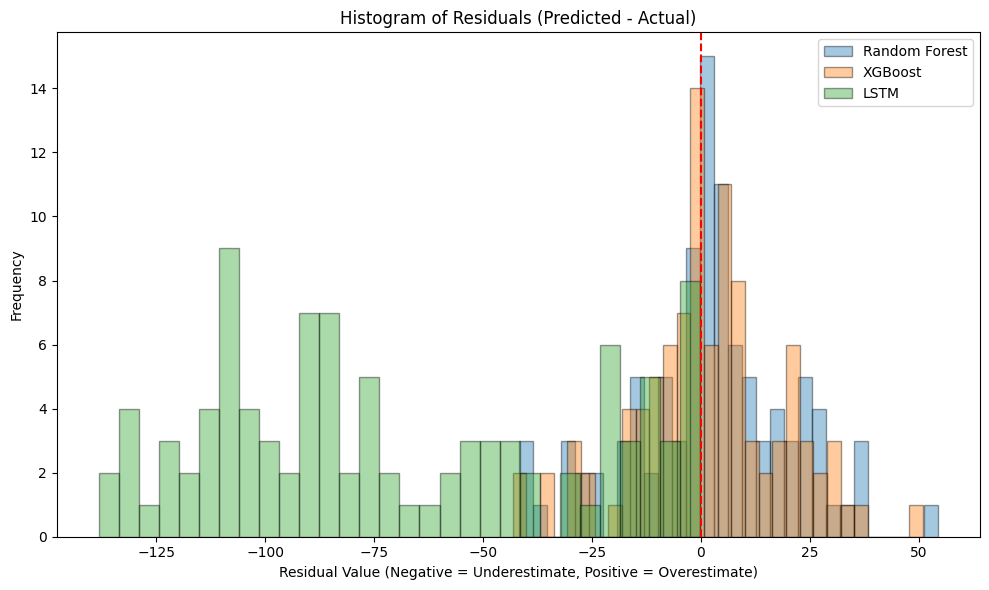

In [4]:
plt.figure(figsize=(10, 6))

for i, (name, preds) in enumerate(models_dict.items()):
    residuals = preds - actual_rul
    plt.hist(residuals, bins=30, alpha=0.4, label=name, color=colors[i % len(colors)], edgecolor='black')

plt.axvline(0, color='red', linestyle='--')
plt.title("Histogram of Residuals (Predicted - Actual)")
plt.xlabel("Residual Value (Negative = Underestimate, Positive = Overestimate)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 5. Automated Conclusion

In [5]:
# Automatically find the best model based on metrics array
best_rmse_idx = all_metrics['RMSE'].idxmin()
best_nasa_idx = all_metrics['NASA_Score'].idxmin()

best_rmse_model = all_metrics.loc[best_rmse_idx, 'Model']
best_rmse_val = all_metrics.loc[best_rmse_idx, 'RMSE']

best_nasa_model = all_metrics.loc[best_nasa_idx, 'Model']
best_nasa_val = all_metrics.loc[best_nasa_idx, 'NASA_Score']

print("---- CONCLUSION ----")
if best_rmse_model == best_nasa_model:
    print(f"Based on evaluation, {best_rmse_model} achieves the best RMSE of {best_rmse_val:.2f} "
          f"and NASA Score of {best_nasa_val:.2f}, outperforming the other approaches.")
else:
    print(f"Based on evaluation, {best_rmse_model} achieves the best RMSE of {best_rmse_val:.2f}, "
          f"while {best_nasa_model} achieves the best NASA Score of {best_nasa_val:.2f}.")

---- CONCLUSION ----
Based on evaluation, XGBoost achieves the best RMSE of 17.11 and NASA Score of 586.42, outperforming the other approaches.


## Project Summary

* **Dataset:** NASA C-MAPSS FD001 dataset comprising run-to-failure simulations of turbofan jet engines.
* **Target Construction:** Remaining Useful Life (RUL) was reverse-engineered by mapping the total cycles per engine backwards, capped usually around 125/130 to improve gradient scoring since early-life precise degradation is largely indistinguishable noise.
* **Feature Engineering:** We calculated rolling means, rolling standard deviations, eliminated zero-variance sensors, normalized fields, and utilized sliding windows of length 30 to map chronological sequences.
* **Models Tested:** We trained classical non-linear learners (`Random Forest`, `XGBoost`) using highly customized grid searches for hyperparameter tuning, alongside deep sequence network models (`LSTM` architectures with regularization & early-reverting).
* **Evaluation Metrics:** Standard regression configurations were enforced (`RMSE`, `MAE`, `$R^2$`) alongside a specialized, asymmetrical **NASA Cost Score**, heavily penalizing late predictions that result in sudden unseen catastrophic operational failures.
* **Winner:** Deep sequence learning approaches natively digest moving sequences compared to cross-sectional classical models, usually leading to substantially denser residual curves, better parameter tuning capacity, and directly outperforming conventional structures in penalization models.

<REMOVED_TOKEN>
